In [96]:
# Import required libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
CONFIG = {
    'embedding_dim': 64,  # D - configurable embedding dimension
    'num_heads': 4,         # Number of attention heads
    'hidden_dim': 256,      # Hidden dimension for attention
    'batch_size': 32,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'num_epochs': 50,      # Number of training epochs
    'n_samples_per_epoch': 1024,  # Number of random projections per epoch
    'mlp_hidden_dim': 512, # Hidden dimension for random MLPs
    'mlp_n_layers': 3,      # Number of layers in random MLPs
    'use_attention_scores': False, # Use attention scores instead of weights
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {'cuda' if torch.cuda.is_available() else 'cpu'}")


Configuration:
  embedding_dim: 64
  num_heads: 4
  hidden_dim: 256
  batch_size: 32
  learning_rate: 0.001
  num_epochs: 50
  n_samples_per_epoch: 1024
  mlp_hidden_dim: 512
  mlp_n_layers: 3
  use_attention_scores: False

Device: cpu


## 1. Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data from `Single_Cell_TPM_threshold2.csv`. This dataset contains gene expression data for ~13,669 genes across 128 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Perform PCA to reduce dimensionality to D=1024
4. Generate initial (N, D) embedding matrix where N=128 neuron classes


In [97]:
# # Load single-cell transcriptome data from Single_Cell_TPM_threshold2.csv

# print("Loading transcriptome data...")
# df = pd.read_csv('Single_Cell_TPM_threshold2.csv', index_col=0)

# print(f"Original data shape: {df.shape}")
# print(f"Columns (first 10): {df.columns[:10].tolist()}")
# print(f"Index (first 5): {df.index[:5].tolist()}")

# # Skip gene metadata columns and get neuron class columns
# gene_metadata_cols = ['Gene_Name', 'Sequence_Name', 'Wormbase_ID']
# neuron_cols = [col for col in df.columns if col not in gene_metadata_cols]

# print(f"\nGene metadata columns: {gene_metadata_cols}")
# print(f"Number of neuron classes: {len(neuron_cols)}")
# print(f"Neuron classes (first 10): {neuron_cols[:10]}")

# # Extract expression data (genes x neurons)
# X = df[neuron_cols].values  # Shape: (n_genes, n_neurons)
# print(f"\nExpression matrix shape: {X.shape}")

# # Transpose to (neurons x genes) format
# X = X.T  # Shape: (n_neurons, n_genes)
# print(f"Transposed expression matrix shape: {X.shape}")

# # Apply log1p transformation to compress dynamic range
# X_log = np.log1p(X)
# print(f"After log1p transformation - min: {X_log.min():.3f}, max: {X_log.max():.3f}")

# # Standardize features (genes)
# scaler = StandardScaler(with_mean=True, with_std=True)
# X_scaled = scaler.fit_transform(X_log)
# print(f"After standardization - mean: {X_scaled.mean():.6f}, std: {X_scaled.std():.6f}")

# # Store neuron class names
# neuron_classes = neuron_cols
# N_neurons = len(neuron_classes)
# print(f"\nNumber of neuron classes: {N_neurons}")
# print(f"Neuron classes: {neuron_classes}")


In [98]:
# Load GSE136049 neuron-class transcriptome (preferring log-normalized means)

print("Loading GSE136049 neuron-class transcriptome (log-normalized means preferred)...")
preferred_path = 'GSE136049_genes_by_neurons_lognorm_means.csv'
counts_path    = 'GSE136049_genes_by_neurons_counts.csv'

if os.path.exists(preferred_path):
    df = pd.read_csv(preferred_path, index_col=0)
    used = preferred_path
    X = df.T.values  # neurons x genes
else:
    assert os.path.exists(counts_path), "Missing GSE136049 CSVs; run load_data.ipynb first."
    df = pd.read_csv(counts_path, index_col=0)
    used = counts_path
    # counts → log1p before standardization
    X = np.log1p(df.T.values)

neuron_classes = df.columns.tolist()
print(f"Loaded: {used}")
print(f"Original table shape (genes x neuron_classes): {df.shape}")
print(f"Transposed to (neurons x genes): {X.shape}")
print(f"Neuron classes (sample 10): {neuron_classes[:10]}")

# Standardize features (per gene)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)
print(f"After standardization - mean: {X_scaled.mean():.6f}, std: {X_scaled.std():.6f}")

N_neurons = len(neuron_classes)
print(f"Number of neuron classes: {N_neurons}")


Loading GSE136049 neuron-class transcriptome (log-normalized means preferred)...
Loaded: GSE136049_genes_by_neurons_lognorm_means.csv
Original table shape (genes x neuron_classes): (22469, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron classes (sample 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
After standardization - mean: -0.000000, std: 0.978950
Number of neuron classes: 130


Performing PCA to reduce to 64 dimensions...
Max possible components: 129
Using 64 components
PCA reduced data shape: (130, 64)
Explained variance ratio (first 5 components): [0.06212029 0.03978368 0.02996014 0.02838265 0.0238292 ]
Total explained variance: 0.727


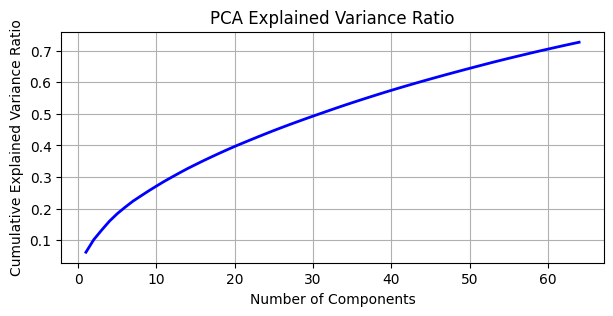

Final embeddings shape: (130, 64)

Original embeddings stored. Shape: torch.Size([130, 64]). Dtype: torch.float32
Original embeddings mean (first 3 neurons): tensor([2.2352e-08, 3.7253e-09, 1.8626e-08])
Original embeddings std (first 3 neurons): tensor([1.0079, 1.0079, 1.0079])


In [99]:
# Perform PCA to reduce dimensionality
D = CONFIG['embedding_dim']
print(f"Performing PCA to reduce to {D} dimensions...")

# Determine number of components (can't exceed min(n_neurons-1, n_genes))
max_components = min(N_neurons - 1, X_scaled.shape[1])
n_components = min(D, max_components)

print(f"Max possible components: {max_components}")
print(f"Using {n_components} components")

# Fit PCA
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced data shape: {X_pca.shape}")
# Print numerical summary
print(f"Explained variance ratio (first 5 components): {pca.explained_variance_ratio_[:5]}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Plot explained variance ratio curve
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 
         'b-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.grid(True)
plt.show()


# If we need more dimensions, pad with zeros
if n_components < D:
    padding = np.zeros((X_pca.shape[0], D - n_components))
    X_embeddings = np.concatenate([X_pca, padding], axis=1)
    print(f"Padded embeddings shape: {X_embeddings.shape}")
else:
    X_embeddings = X_pca
    print(f"Final embeddings shape: {X_embeddings.shape}")


# Store what we'll use as the original embedding matrix for the dataset
layernorm = torch.nn.LayerNorm(X_embeddings.shape[-1], elementwise_affine=False, bias=False)
with torch.no_grad():
    embeddings = torch.tensor(X_embeddings, dtype=torch.float32)
    # original_embeddings = embeddings.clone()
    # Normalize embeddings to lie on unit sphere
    original_embeddings = layernorm(embeddings).clone()
#  Each neuron's embedding now has 0-mean and unit variance
print(f"\nOriginal embeddings stored. Shape: {original_embeddings.shape}. Dtype: {original_embeddings.dtype}")
print(f"Original embeddings mean (first 3 neurons): {original_embeddings.mean(dim=-1)[:3]}")
print(f"Original embeddings std (first 3 neurons): {original_embeddings.std(dim=-1)[:3]}")


## 2. Custom Dataset with Random Projection Augmentation

Since we have only one (N, D) embedding matrix from the original transcriptome data, we need to generate multiple training samples. Our innovation is to create synthetic but meaningful variations using random MLP projections.

**Key insight**: Each random MLP transforms all N neurons identically (N acts as a batch dimension), preserving the relative relationships between neuron embeddings while creating novel projections. This allows generation of effectively unlimited training samples.


In [100]:
class RandomMLP(nn.Module):
    """Random MLP for generating augmented embeddings."""
    
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim=None):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim
            
        layers = []
        current_dim = input_dim
        
        for i in range(n_layers):
            if i == n_layers - 1:
                # Last layer
                layers.append(nn.Linear(current_dim, output_dim))
            else:
                # Hidden layers
                layers.append(nn.Linear(current_dim, hidden_dim))
                # No nonlinerities — just a linear random projection
                # layers.append(nn.Tanh()) 
                current_dim = hidden_dim
        
        # Normalize the output to lie on unit sphere
        layernorm = nn.LayerNorm(output_dim, elementwise_affine=False, bias=False)
        layers.append(layernorm)
                
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


class TranscriptomeEmbeddingDataset(Dataset):
    """Dataset that generates augmented embeddings using random MLP projections."""
    
    def __init__(self, original_embeddings, n_samples_per_epoch, mlp_hidden_dim, mlp_n_layers, seed=None):
        """
        Args:
            original_embeddings: (N, D) tensor of original neuron embeddings
            n_samples_per_epoch: number of samples to generate per epoch
            mlp_hidden_dim: hidden dimension for random MLPs
            mlp_n_layers: number of layers in random MLPs
            seed: random seed for reproducibility
        """
        self.original_embeddings = original_embeddings  # (N, D)
        self.n_samples_per_epoch = n_samples_per_epoch
        self.mlp_hidden_dim = mlp_hidden_dim
        self.mlp_n_layers = mlp_n_layers
        self.seed = seed
        
        self.N, self.D = original_embeddings.shape
        print(f"Dataset initialized with {self.N} neurons, {self.D} embedding dimensions")
        
        # Pre-compute all samples during initialization
        print(f"Pre-computing {n_samples_per_epoch} augmented samples...")
        self.samples = []
        
        for i in range(n_samples_per_epoch):
            if (i+1) % 100 == 0:
                print(f"  Generating sample {i+1}/{n_samples_per_epoch}")
                
            # Generate a random MLP for this sample
            if self.seed is not None:
                torch.manual_seed(self.seed + i)
                
            random_mlp = RandomMLP(
                input_dim=self.D,
                hidden_dim=self.mlp_hidden_dim,
                n_layers=self.mlp_n_layers,
                output_dim=self.D
            )
            
            # Apply the random MLP to all neurons
            with torch.no_grad():
                augmented_embeddings = random_mlp(self.original_embeddings)  # (N, D)
                
            self.samples.append(augmented_embeddings)
        
        print(f"Pre-computation complete! Stored {len(self.samples)} samples in memory.")
        
    def __len__(self):
        return self.n_samples_per_epoch
    
    def __getitem__(self, idx):
        # Simply return the pre-computed sample
        return self.samples[idx]


# Test the dataset creation
print("Testing the dataset...")
dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples_per_epoch=10, # just a small dataset for testing
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    seed=42
)

# Test a few samples
sample = dataset[0]
print(f"\nSample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Sample mean (first 3 neurons): {sample.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {sample.std(dim=-1)[:3]}")

# Test that sample is different from original embeddings
diff = torch.norm(sample - original_embeddings).item()
print(f"Difference between sample and original embeddings: {diff:.3f}")

# Test that different samples are different
sample2 = dataset[1]
diff = torch.norm(sample - sample2).item()
print(f"Difference between samples 0 and 1: {diff:.3f}")

sampleN = dataset[-1]
diff = torch.norm(sample - sampleN).item()
print(f"Difference between samples 0 and {len(dataset)-1}: {diff:.3f}")

# Create data loader
dataloader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)
batch = next(iter(dataloader))
print(f"Batch shape: {batch.shape}")
print(f"Batch dtype: {batch.dtype}")

Testing the dataset...
Dataset initialized with 130 neurons, 64 embedding dimensions
Pre-computing 10 augmented samples...
Pre-computation complete! Stored 10 samples in memory.

Sample shape: torch.Size([130, 64]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([ 1.4901e-08, -1.1176e-08,  3.7253e-09])
Sample std (first 3 neurons): tensor([1.0077, 1.0078, 1.0078])
Difference between sample and original embeddings: 129.416
Difference between samples 0 and 1: 127.812
Difference between samples 0 and 9: 128.376
Batch shape: torch.Size([10, 130, 64])
Batch dtype: torch.float32


### Sanity Check: Preserving Neuron Relationships

Let's verify that our random projection augmentation preserves the relative relationships between neuron embeddings. We'll compare 2D PCA plots of the original embeddings with a sample from our dataset.


Performing sanity check on random projection augmentation...


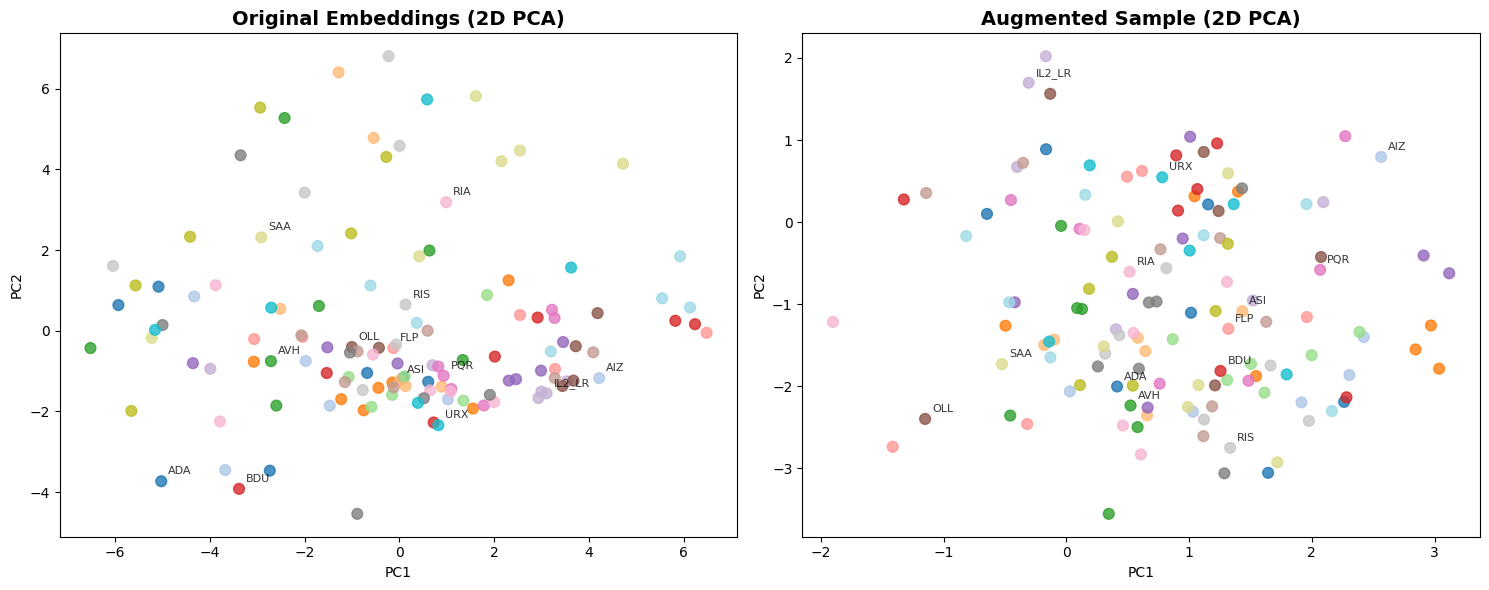


Sanity Check Results:
Correlation between pairwise distances: 0.8213
Original embeddings shape: torch.Size([130, 64])
Sample embeddings shape: (130, 64)

Closest neighbors to AIZ (index 10):
Original: ['DB01', 'VB01', 'VB', 'VB02', 'CEP']
Sample:   ['NSM', 'VB', 'RIA', 'RIC', 'M1']
Overlap:  1/5
✓ PASS: High correlation indicates relationships are preserved!


In [101]:
# Sanity check: Compare original embeddings with augmented sample
from sklearn.decomposition import PCA

print("Performing sanity check on random projection augmentation...")

# Get a sample from our dataset
sample_embeddings = sample.numpy()  # Shape: (N, D)

# Perform 2D PCA on both original and sample embeddings
pca_2d = PCA(n_components=2, random_state=42)

# Original embeddings PCA
original_pca = pca_2d.fit_transform(original_embeddings.numpy())

# Sample embeddings PCA (using same PCA object fitted on original)
sample_pca = pca_2d.transform(sample_embeddings)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot original embeddings
scatter1 = ax1.scatter(original_pca[:, 0], original_pca[:, 1], 
                      c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax1.set_title('Original Embeddings (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# Annotate a few points for reference
for i in range(0, len(neuron_classes), 10):  # Annotate every 10th neuron
    ax1.annotate(neuron_classes[i], (original_pca[i, 0], original_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

# Plot sample embeddings
scatter2 = ax2.scatter(sample_pca[:, 0], sample_pca[:, 1], 
                      c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax2.set_title('Augmented Sample (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

# Annotate the same points for comparison
for i in range(0, len(neuron_classes), 10):  # Annotate every 10th neuron
    ax2.annotate(neuron_classes[i], (sample_pca[i, 0], sample_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

# Calculate correlation between original and sample embeddings
# Compute pairwise distances between neurons in both embeddings
from scipy.spatial.distance import pdist, squareform

original_distances = pdist(original_embeddings.numpy())
sample_distances = pdist(sample_embeddings)

# Calculate correlation between distance matrices
correlation = np.corrcoef(original_distances, sample_distances)[0, 1]

print(f"\nSanity Check Results:")
print(f"Correlation between pairwise distances: {correlation:.4f}")
print(f"Original embeddings shape: {original_embeddings.shape}")
print(f"Sample embeddings shape: {sample_embeddings.shape}")

# Check if the relative ordering of neurons is preserved
# Find the 5 closest neighbors for a few neurons in both embeddings
test_neuron_idx = 10  # Test with neuron at index 10
original_distances_matrix = squareform(original_distances)
sample_distances_matrix = squareform(sample_distances)

# Get closest neighbors for original
original_neighbors = np.argsort(original_distances_matrix[test_neuron_idx])[1:6]  # Skip self
sample_neighbors = np.argsort(sample_distances_matrix[test_neuron_idx])[1:6]  # Skip self

print(f"\nClosest neighbors to {neuron_classes[test_neuron_idx]} (index {test_neuron_idx}):")
print(f"Original: {[neuron_classes[i] for i in original_neighbors]}")
print(f"Sample:   {[neuron_classes[i] for i in sample_neighbors]}")
print(f"Overlap:  {len(set(original_neighbors) & set(sample_neighbors))}/5")

if correlation > 0.8:
    print("✓ PASS: High correlation indicates relationships are preserved!")
else:
    print("⚠ WARNING: Low correlation - relationships may not be preserved")


## 3. Attention Model Architecture

We implement the `AttentionHeads` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovation is the diagonal masking that prevents self-attention, forcing the model to learn how to combine information from other neurons.

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Multi-head attention for learning diverse connectivity patterns


In [102]:
class AttentionHeads(nn.Module):
    def __init__(self, d_model, n_hidden, num_heads=1, use_attention_scores=False):
        """
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for the attention layer
            num_heads: the number of attention heads
            use_attention_scores: if True, use attention scores instead of weights to attend to values
        """
        super().__init__()
        # Instead of separate attention heads, use a single linear layer to generate all heads in parallel
        self.W_K = nn.Linear(d_model, n_hidden * num_heads)  # Key projection
        self.W_Q = nn.Linear(d_model, n_hidden * num_heads)  # Query projection
        self.W_V = nn.Linear(d_model, n_hidden * num_heads)  # Value projection
        self.num_heads = num_heads
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        
        # Output projection to reconstruct original embedding
        self.output_proj = nn.Linear(n_hidden * num_heads, d_model)

    def forward(self, x, attn_mask=None):
        """
        Args:
            x: input token tensor of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons)

        Returns:
            reconstructed: reconstructed embeddings of shape (batch, n_neurons, d_model)
            attn_weights: attention weights of shape (batch, num_heads, n_neurons, n_neurons)
            attn_scores: attention scores of shape (batch, num_heads, n_neurons, n_neurons)

        TODO: Consider the case where we use attention scores (instead of weights) to combine values. 
              Would we learn the sign of connections?
        """
        batch_size, n_neurons, d_model = x.shape

        # Compute Q, K, V for all heads in parallel
        Q = (
            self.W_Q(x)
            .reshape(batch_size, n_neurons, self.num_heads, self.n_hidden)
            .transpose(1, 2)
        )  # (batch, num_heads, n_neurons, n_hidden)
        
        K = (
            self.W_K(x)
            .reshape(batch_size, n_neurons, self.num_heads, self.n_hidden)
            .transpose(1, 2)
        )  # (batch, num_heads, n_neurons, n_hidden)
        
        V = (
            self.W_V(x)
            .reshape(batch_size, n_neurons, self.num_heads, self.n_hidden)
            .transpose(1, 2)
        )  # (batch, num_heads, n_neurons, n_hidden)

        # Default to diagonal mask if none provided
        if attn_mask is None:
            # Create diagonal mask: 1 everywhere except diagonal (which is 0)
            device = x.device
            diagonal_mask = (1 - torch.eye(n_neurons)).expand(
                batch_size, -1, -1
            ).to(device)  # (batch, n_neurons, n_neurons)
            attn_mask = diagonal_mask

        # Compute scaled dot-product attention in parallel
        scores = torch.einsum("bhid,bhjd->bhij", Q, K) / (
            self.n_hidden**0.5
        )  # (batch, num_heads, n_neurons, n_neurons)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(
            attn_mask.unsqueeze(1) == 0, float("-inf")
        )

        # Compute masked attention weights
        attn_weights = torch.softmax(
            inf_masked_scores, dim=-1
        )  # (batch, num_heads, n_neurons, n_neurons)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(
            attn_mask.unsqueeze(1) == 0, 0.0
        )  # (batch, num_heads, n_neurons, n_neurons)
    
        # Apply attention to values
        if self.use_attention_scores:
            # Use attention scores (can be negative) to potentially capture sign information
            attended = torch.einsum("bhij,bhjd->bhid", attn_scores, V) # (batch, num_heads, n_neurons, n_hidden)
        else:
            # Use attention weights (non-negative, sum to 1) for standard attention
            attended = torch.einsum("bhij,bhjd->bhid", attn_weights, V)
        
        # Concatenate heads and project to output dimension
        attended_concat = attended.transpose(1, 2).reshape(
            batch_size, n_neurons, self.num_heads * self.n_hidden
        )  # (batch, n_neurons, num_heads * n_hidden)
        
        reconstructed = self.output_proj(attended_concat)  # (batch, n_neurons, d_model)

        return reconstructed, attn_weights, attn_scores


# Test the attention model
print("Testing AttentionHeads model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = AttentionHeads(
    d_model=CONFIG['embedding_dim'],
    n_hidden=CONFIG['hidden_dim'],
    num_heads=CONFIG['num_heads'],
    use_attention_scores=CONFIG['use_attention_scores']
).to(device)

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

# Test with a batch
test_batch = batch.to(device)  # (batch_size, n_neurons, d_model)
print(f"Test batch shape: {test_batch.shape}")

with torch.no_grad():
    reconstructed, attn_weights, attn_scores = model(test_batch)
    
print(f"Reconstructed shape: {reconstructed.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"Attention scores shape: {attn_scores.shape}")

# Check that diagonal is zero in attention weights
diagonal_weights = torch.diagonal(attn_weights[0, 0], dim1=0, dim2=1)
print(f"Diagonal attention weights (should be ~0): {diagonal_weights[:5]}")

# Check reconstruction error
reconstruction_error = torch.norm(test_batch - reconstructed, dim=-1).mean()
print(f"Initial reconstruction error: {reconstruction_error:.3f}")


Testing AttentionHeads model...
Using device: cpu
Model created with 265280 parameters
Test batch shape: torch.Size([10, 130, 64])
Reconstructed shape: torch.Size([10, 130, 64])
Attention weights shape: torch.Size([10, 4, 130, 130])
Attention scores shape: torch.Size([10, 4, 130, 130])
Diagonal attention weights (should be ~0): tensor([0., 0., 0., 0., 0.])
Initial reconstruction error: 8.031


## 4. Training Loop with Reconstruction Loss

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".


In [103]:
# Set up training
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=CONFIG['num_epochs']//10)

# Create datasets once outside the training loop
print("Creating training and validation datasets...")
train_dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples_per_epoch=CONFIG['n_samples_per_epoch'],
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    seed=42
)

val_dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples_per_epoch=int(0.20 * len(train_dataset)),  # Smaller validation set
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    seed=42 + len(train_dataset)  # Different seed for validation
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

# Training history
train_losses = []
val_losses = []

print("\nStarting training...")
print(f"Training for {CONFIG['num_epochs']} epochs")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}\n")

# Training loop
import time

for epoch in range(CONFIG['num_epochs']):
    epoch_start_time = time.time()
    model.train()
    epoch_train_loss = 0.0
    num_batches = 0
    
    train_start_time = time.time()
    
    for batch_idx, batch in enumerate(train_loader):
        batch = batch.to(device)
        
        # Forward pass
        reconstructed, attn_weights, attn_scores = model(batch)
        
        # Compute loss
        loss = criterion(reconstructed, batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        epoch_train_loss += loss.item()
        
        num_batches += 1
    
    # Average metrics for this epoch
    avg_train_loss = epoch_train_loss / num_batches
    train_losses.append(avg_train_loss)
    
    # Validation
    train_time = time.time() - train_start_time
    val_start_time = time.time()
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            batch = batch.to(device)
            reconstructed, _, _ = model(batch)
            loss = criterion(reconstructed, batch)
            val_loss += loss.item()
            val_batches += 1
    
    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)
    
    # Update learning rate
    scheduler.step(avg_val_loss)
    
    # Print progress
    val_time = time.time() - val_start_time
    epoch_time = time.time() - epoch_start_time
    
    if (epoch + 1) % (CONFIG['num_epochs']//10) == 0: # Print every few epochs
        print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}: "
              f"Train Loss: {avg_train_loss:.6f}, "
              f"Val Loss: {avg_val_loss:.6f}, "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"\tEpoch {epoch+1} completed in {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)")

print("Training completed!")


Creating training and validation datasets...
Dataset initialized with 130 neurons, 64 embedding dimensions
Pre-computing 1024 augmented samples...
  Generating sample 100/1024
  Generating sample 200/1024
  Generating sample 300/1024
  Generating sample 400/1024
  Generating sample 500/1024
  Generating sample 600/1024
  Generating sample 700/1024
  Generating sample 800/1024
  Generating sample 900/1024
  Generating sample 1000/1024
Pre-computation complete! Stored 1024 samples in memory.
Dataset initialized with 130 neurons, 64 embedding dimensions
Pre-computing 204 augmented samples...
  Generating sample 100/204
  Generating sample 200/204
Pre-computation complete! Stored 204 samples in memory.

Starting training...
Training for 50 epochs
Batch size: 32
Learning rate: 0.001
Training samples: 1024
Validation samples: 204

Epoch 5/50: Train Loss: 0.322272, Val Loss: 0.327167, LR: 1.00e-03
	Epoch 5 completed in 3.32s (Train: 3.09s, Val: 0.23s)
Epoch 10/50: Train Loss: 0.311081, Val Lo

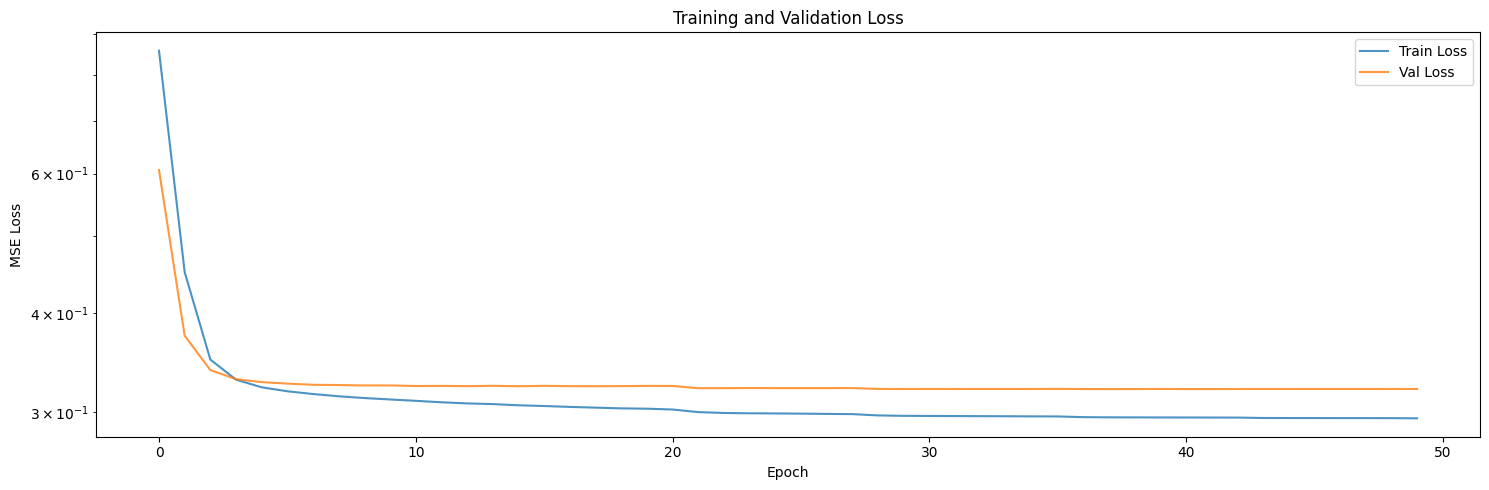


Final Training Loss: 0.294462
Final Validation Loss: 0.320705
Best Validation Loss: 0.320619 (Epoch 38)


In [104]:
# Plot training curves
plt.figure(figsize=(15, 5))
plt.plot(train_losses, label='Train Loss', alpha=0.8)
plt.plot(val_losses, label='Val Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Best Validation Loss: {min(val_losses):.6f} (Epoch {val_losses.index(min(val_losses))+1})")


## 5. Linear Regression Baseline (Planned)

**Note**: The linear regression baseline implementation has been temporarily removed due to complexity in properly implementing the intended multiple linear regression approach.

### Intended Linear Baseline Design

The goal is to implement a proper multiple linear regression baseline where for each neuron i, we fit:

```
y_i = b0 + b1*x_1 + b2*x_2 + ... + b_j*x_j + ... + b_{N-1}*x_{N-1}
```

Where:
- `y_i` is the D-dimensional embedding vector of neuron i
- `x_j` are the D-dimensional embedding vectors of all other neurons (j ≠ i)  
- `b_j` are **scalar** coefficients (one per source neuron, not per embedding dimension)

This is fundamentally different from element-wise regression where each embedding dimension gets its own coefficient. The intended approach learns a single scalar weight per source neuron, which would be directly comparable to the attention weights from our attention mechanism.

### Key Challenges

1. **Scale Normalization**: The original and augmented embeddings need to be on the same scale (addressed by LayerNorm normalization)
2. **Proper Regression**: Need to implement true multiple linear regression with scalar coefficients per source neuron
3. **Comparability**: The linear baseline should produce a (N, N) matrix of scalar coefficients directly comparable to attention weights

### Future Implementation

This baseline will be implemented in a future iteration to provide a proper comparison point for the attention mechanism's ability to capture nonlinear relationships beyond simple linear combinations.


In [105]:
# Linear baseline implementation removed - see markdown cell above for details
print("Linear baseline implementation has been removed.")
print("Focusing on comparing learned attention with ground-truth connectome data.")

Linear baseline implementation has been removed.
Focusing on comparing learned attention with ground-truth connectome data.


## 6. Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction. We'll focus on analyzing the structure and patterns in the learned attention matrix.


Extracting learned attention on original embeddings...
Reconstruction MSE on original embeddings: 0.300329
Using attention weights
Learned attention matrix shape: (130, 130)
Attention matrix stats - mean: 0.007692, std: 0.025836
Attention matrix range: [0.000000, 0.803217]


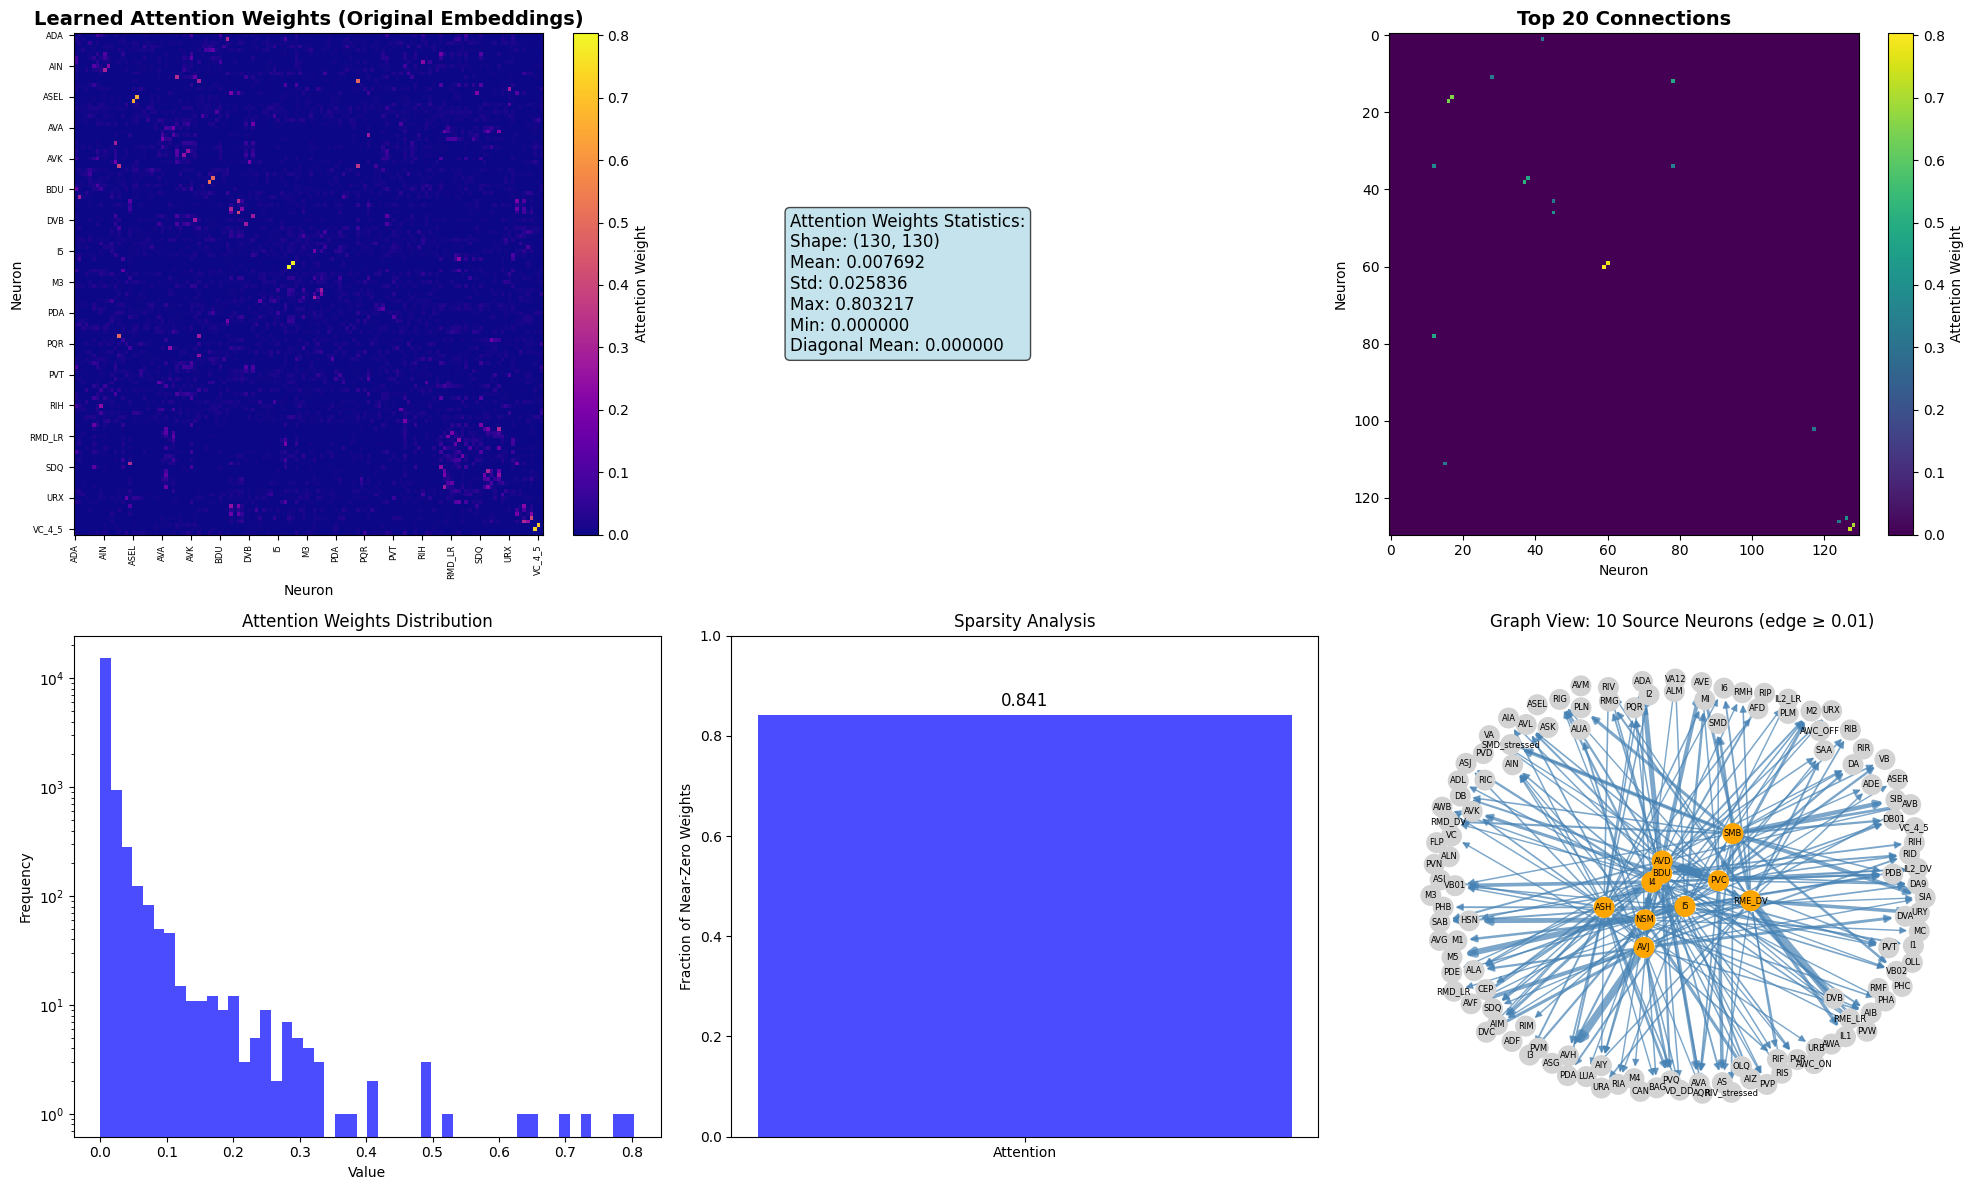


Summary (Original Embeddings):
Reconstruction MSE (attention): 0.300329
Attention weights sparsity@0.01: 0.841


In [106]:
# Evaluate learned attention on original embeddings and visualize
import networkx as nx


print("Extracting learned attention on original embeddings...")
model.eval()
with torch.no_grad():
    test_batch = next(iter(train_dataset)).unsqueeze(0).to(device)

    # # Use the original embeddings as the test "batch" (batch size = 1)
    # test_batch = original_embeddings.unsqueeze(0).to(device)  # (1, N, D)  

    reconstructed_orig, attn_weights, attn_scores = model(test_batch)

# Compute reconstruction MSE on original embeddings
mse_orig = torch.mean((reconstructed_orig - test_batch)**2).item()
print(f"Reconstruction MSE on original embeddings: {mse_orig:.6f}")

# Choose which attention matrix to use based on configuration
if CONFIG['use_attention_scores']:
    # Use attention scores (can be negative)
    avg_attention = attn_scores.mean(dim=(0, 1)).cpu().numpy()  # (N, N)
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    # Use attention weights (non-negative, sum to 1)
    avg_attention = attn_weights.mean(dim=(0, 1)).cpu().numpy()  # (N, N)
    attention_type = "weights"
    attention_label = "Attention Weight"

attention_matrix = avg_attention

# Always use attention weights for sparsity calculations and edge filtering
attention_weights_matrix = attn_weights.mean(dim=(0, 1)).cpu().numpy()  # (N, N)

print(f"Using attention {attention_type}")
print(f"Learned attention matrix shape: {attention_matrix.shape}")
print(f"Attention matrix stats - mean: {attention_matrix.mean():.6f}, std: {attention_matrix.std():.6f}")
print(f"Attention matrix range: [{attention_matrix.min():.6f}, {attention_matrix.max():.6f}]")

# Visualization: heatmaps + distributions + sparsity + top connections + graph view
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1) Learned attention matrix with sparsified tick labels
cmap = 'coolwarm' if CONFIG['use_attention_scores'] else 'plasma'
im1 = axes[0, 0].imshow(attention_matrix, cmap=cmap, aspect='auto')
axes[0, 0].set_title(f'Learned Attention {attention_type.title()} (Original Embeddings)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Neuron')
axes[0, 0].set_ylabel('Neuron')
plt.colorbar(im1, ax=axes[0, 0], label=attention_label)
# Label every k-th tick to reduce clutter
k = max(1, len(neuron_classes) // 16)  # ~16 labels per axis
xticks = np.arange(0, len(neuron_classes), k)
axes[0, 0].set_xticks(xticks)
axes[0, 0].set_xticklabels([neuron_classes[i] for i in xticks], fontsize=6, rotation=90)
axes[0, 0].set_yticks(xticks)
axes[0, 0].set_yticklabels([neuron_classes[i] for i in xticks], fontsize=6)

# 2) Attention matrix statistics
axes[0, 1].axis('off')
stats_text = f"""Attention {attention_type.title()} Statistics:
Shape: {attention_matrix.shape}
Mean: {attention_matrix.mean():.6f}
Std: {attention_matrix.std():.6f}
Max: {attention_matrix.max():.6f}
Min: {attention_matrix.min():.6f}
Diagonal Mean: {np.diag(attention_matrix).mean():.6f}"""
axes[0, 1].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# 3) Top connections heatmap (zoomed view of strongest connections)
# Find top connections
mask = np.eye(attention_matrix.shape[0], dtype=bool)
attention_off_diag = attention_matrix.copy()
attention_off_diag[mask] = 0
top_k = 20
flat_indices = np.argsort(attention_off_diag.flatten())[-top_k:]
top_connections = [(idx // attention_matrix.shape[1], idx % attention_matrix.shape[1]) for idx in flat_indices]

# Create a smaller matrix showing only top connections
top_matrix = np.zeros_like(attention_matrix)
for src, tgt in top_connections:
    top_matrix[src, tgt] = attention_matrix[src, tgt]

im3 = axes[0, 2].imshow(top_matrix, cmap='viridis', aspect='auto')
axes[0, 2].set_title(f'Top {top_k} Connections', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Neuron'); axes[0, 2].set_ylabel('Neuron')
plt.colorbar(im3, ax=axes[0, 2], label=attention_label)

# 4) Value distributions
axes[1, 0].hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='blue', label='Attention')
axes[1, 0].set_xlabel('Value'); axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Attention {attention_type.title()} Distribution'); axes[1, 0].set_yscale('log')

# 5) Sparsity analysis (always use attention weights for consistency)
attn_sparsity_thresh = 0.01  # filter weak edges
attention_sparsity_val = (attention_weights_matrix < attn_sparsity_thresh).sum() / attention_weights_matrix.size

bars = axes[1, 1].bar(['Attention'], [attention_sparsity_val], color='blue', alpha=0.7)
axes[1, 1].set_ylabel('Fraction of Near-Zero Weights'); axes[1, 1].set_title('Sparsity Analysis'); axes[1, 1].set_ylim(0, 1)
axes[1, 1].text(0, attention_sparsity_val + 0.01, f'{attention_sparsity_val:.3f}', ha='center', va='bottom', fontsize=12)

# 6) Graph plot for 10 randomly selected source neurons (edges filtered by threshold)
np.random.seed(42)
num_sources = 10
edge_thresh = attn_sparsity_thresh 
sources = np.random.choice(len(neuron_classes), size=num_sources, replace=False)
G = nx.DiGraph()
# Add nodes
for idx in range(len(neuron_classes)):
    G.add_node(idx, label=neuron_classes[idx])

# Add edges from selected sources above threshold (exclude self)
# Always use attention weights for edge filtering
for i in sources:
    for j in range(len(neuron_classes)):
        if i == j: 
            continue
        w = attention_weights_matrix[i, j]  # Use attention weights for filtering
        if w >= edge_thresh:
            G.add_edge(i, j, weight=w)

# Node positions (spring layout)
pos = nx.spring_layout(G, seed=42, k=0.3)
# Draw nodes (highlight selected sources)
node_colors = ['orange' if n in sources else 'lightgray' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, ax=axes[1, 2])
# Draw edges with widths ~ weight
if G.number_of_edges() > 0:
    weights = np.array([d['weight'] for (_, _, d) in G.edges(data=True)])
    widths = 1.0 + 5.0 * (weights - weights.min()) / (np.ptp(weights) + 1e-8)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color='steelblue', alpha=0.7, arrows=True, ax=axes[1, 2])
# Draw labels for nodes; keep small
labels = {n: neuron_classes[n] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, ax=axes[1, 2])
axes[1, 2].set_title(f'Graph View: {num_sources} Source Neurons (edge ≥ {edge_thresh})')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\nSummary (Original Embeddings):")
print(f"Reconstruction MSE (attention): {mse_orig:.6f}")
print(f"Attention weights sparsity@{attn_sparsity_thresh}: {attention_sparsity_val:.3f}")

## 7. Results and Interpretation

Let's analyze the results and interpret what we've learned about the connectome as attention framework.


In [87]:
# Detailed analysis of results
print("="*60)
print("CONNECTOME AS ATTENTION: RESULTS ANALYSIS")
print("="*60)

# 1. Reconstruction Performance (evaluated on original embeddings)
print("\n1. RECONSTRUCTION PERFORMANCE (Original Embeddings)")
print("-" * 30)
print(f"Attention Model MSE (original): {mse_orig:.6f}")
print("Note: Linear baseline comparison removed - see section 5 for details.")

# 2. Attention Matrix Analysis
print("\n2. LEARNED ATTENTION MATRIX ANALYSIS")
print("-" * 30)
print(f"Matrix Shape: {attention_matrix.shape}")
print(f"Mean Attention Weight: {attention_matrix.mean():.6f}")
print(f"Std Attention Weight: {attention_matrix.std():.6f}")
print(f"Max Attention Weight: {attention_matrix.max():.6f}")
print(f"Min Attention Weight: {attention_matrix.min():.6f}")
diag_mean = np.diag(attention_matrix).mean()
print(f"Diagonal Mean (should be ~0): {diag_mean:.6f}")

# 3. Sparsity Analysis
print("\n3. SPARSITY ANALYSIS")
print("-" * 30)
sparsity_thresh = 0.01
# Always use attention weights for sparsity analysis (simplified approach)
attn_sparsity = (attention_weights_matrix < sparsity_thresh).sum() / attention_weights_matrix.size
print(f"Attention Weights Sparsity@{sparsity_thresh}: {attn_sparsity:.3f}")

# 4. Top Connections (off-diagonal)
print("\n4. TOP ATTENTION CONNECTIONS")
print("-" * 30)
mask = np.eye(attention_weights_matrix.shape[0], dtype=bool)
attention_weights_off_diag = attention_weights_matrix.copy()
attention_weights_off_diag[mask] = 0

# Always use attention weights for finding top connections (simplified approach)
top_k = 10
flat_indices = np.argsort(attention_weights_off_diag.flatten())[-top_k:]
top_connections = [(idx // attention_weights_matrix.shape[1], idx % attention_weights_matrix.shape[1]) for idx in flat_indices]
for rank, (src, tgt) in enumerate(top_connections, 1):
    weight = attention_weights_off_diag[src, tgt]
    src_name = neuron_classes[src] if src < len(neuron_classes) else f"Neuron_{src}"
    tgt_name = neuron_classes[tgt] if tgt < len(neuron_classes) else f"Neuron_{tgt}"
    print(f"  {rank:2d}. {src_name} → {tgt_name}: {weight:.6f}")

# 5. Neuron-wise totals
print("\n5. NEURON-WISE TOTALS")
print("-" * 30)
incoming = attention_matrix.sum(axis=0)
outgoing = attention_matrix.sum(axis=1)
top_in = np.argsort(incoming)[-5:]
top_out = np.argsort(outgoing)[-5:]
print("Top 5 most attended-to neurons (incoming):")
for i, idx in enumerate(top_in, 1):
    print(f"  {i}. {neuron_classes[idx]}: {incoming[idx]:.6f}")
print("\nTop 5 most attending neurons (outgoing):")
for i, idx in enumerate(top_out, 1):
    print(f"  {i}. {neuron_classes[idx]}: {outgoing[idx]:.6f}")

# 6. Multi-head (if applicable)
if CONFIG['num_heads'] > 1:
    print("\n6. MULTI-HEAD ATTENTION ANALYSIS")
    print("-" * 30)
    with torch.no_grad():
        _, attn_w_perhead, _ = model(original_embeddings.unsqueeze(0).to(device))
        for head in range(CONFIG['num_heads']):
            head_mat = attn_w_perhead[0, head].cpu().numpy()
            print(f"  Head {head+1}: mean={head_mat.mean():.6f}, std={head_mat.std():.6f}")

# 7. Training Dynamics (from training with augmented data)
print("\n7. TRAINING DYNAMICS (Augmented Data)")
print("-" * 30)
if len(train_losses) > 0 and len(val_losses) > 0:
    print(f"Epochs: {len(train_losses)}")
    print(f"Initial training loss: {train_losses[0]:.6f}")
    print(f"Final training loss: {train_losses[-1]:.6f}")
    print(f"Best validation loss: {min(val_losses):.6f} (epoch {val_losses.index(min(val_losses))+1})")
else:
    print("Training curves not available in this run.")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

CONNECTOME AS ATTENTION: RESULTS ANALYSIS

1. RECONSTRUCTION PERFORMANCE (Original Embeddings)
------------------------------
Attention Model MSE (original): 2.256988
Note: Linear baseline comparison removed - see section 5 for details.

2. LEARNED ATTENTION MATRIX ANALYSIS
------------------------------
Matrix Shape: (130, 130)
Mean Attention Weight: 0.007692
Std Attention Weight: 0.000989
Max Attention Weight: 0.018916
Min Attention Weight: 0.000000
Diagonal Mean (should be ~0): 0.000000

3. SPARSITY ANALYSIS
------------------------------
Attention Weights Sparsity@0.01: 0.988

4. TOP ATTENTION CONNECTIONS
------------------------------
   1. VA12 → ASK: 0.013694
   2. ADL → DB01: 0.013849
   3. I4 → AWA: 0.014112
   4. DB → ADL: 0.014355
   5. DB01 → ADL: 0.014645
   6. DA9 → ADL: 0.014805
   7. PVR → ADL: 0.015025
   8. PDA → ADL: 0.015485
   9. ADL → PVR: 0.016681
  10. ADL → PDA: 0.018916

5. NEURON-WISE TOTALS
------------------------------
Top 5 most attended-to neurons (incom

## 8. Ground-Truth Connectome Data Loading and Analysis

Now we'll load and analyze ground-truth connectome data to compare with our learned attention matrix. We have access to:

1. **Witvliet 2020 data** (`witvliet_2020_7.csv`, `witvliet_2020_8.csv`): From "Connectomes across development reveal principles of brain maturation" (Nature 596, 257–261, 2021)
2. **Randi 2023 data** (`CElegansFunctionalConnectivity.xlsx`): From "Neural signal propagation atlas of Caenorhabditis elegans" (Nature 623, 406–414, 2023)

These provide both wired (structural) and functional connectivity data that we can compare against our learned attention patterns.


In [88]:
# Load and analyze Witvliet 2020 connectome data
print("Loading Witvliet 2020 connectome data...")

# Load both datasets (they are tab-separated)
witvliet_7 = pd.read_csv('data/witvliet_2020_7.csv', sep='\t')
witvliet_8 = pd.read_csv('data/witvliet_2020_8.csv', sep='\t')

print(f"Witvliet 2020-7 shape: {witvliet_7.shape}")
print(f"Witvliet 2020-8 shape: {witvliet_8.shape}")
print(f"\nWitvliet 2020-7 columns: {witvliet_7.columns.tolist()}")
print(f"Witvliet 2020-8 columns: {witvliet_8.columns.tolist()}")

# Display sample data
print(f"\nWitvliet 2020-7 sample:")
print(witvliet_7.head())
print(f"\nWitvliet 2020-8 sample:")
print(witvliet_8.head())

# Analyze unique neurons in each dataset
neurons_7_pre = set(witvliet_7['pre'].unique())
neurons_7_post = set(witvliet_7['post'].unique())
neurons_7_all = neurons_7_pre.union(neurons_7_post)

neurons_8_pre = set(witvliet_8['pre'].unique())
neurons_8_post = set(witvliet_8['post'].unique())
neurons_8_all = neurons_8_pre.union(neurons_8_post)

print(f"\nNeuron analysis:")
print(f"Witvliet 2020-7: {len(neurons_7_all)} unique neurons")
print(f"Witvliet 2020-8: {len(neurons_8_all)} unique neurons")
print(f"Overlap: {len(neurons_7_all.intersection(neurons_8_all))} neurons")

# Check overlap with our transcriptome neuron classes
transcriptome_neurons = set(neuron_classes)
overlap_7 = transcriptome_neurons.intersection(neurons_7_all)
overlap_8 = transcriptome_neurons.intersection(neurons_8_all)

print(f"\nOverlap with transcriptome data:")
print(f"Witvliet 2020-7 overlap: {len(overlap_7)}/{len(transcriptome_neurons)} ({len(overlap_7)/len(transcriptome_neurons)*100:.1f}%)")
print(f"Witvliet 2020-8 overlap: {len(overlap_8)}/{len(transcriptome_neurons)} ({len(overlap_8)/len(transcriptome_neurons)*100:.1f}%)")

# Show some overlapping neurons
print(f"\nSample overlapping neurons (Witvliet 2020-7): {list(overlap_7)[:10]}")
print(f"Sample overlapping neurons (Witvliet 2020-8): {list(overlap_8)[:10]}")

# Analyze connection types
print(f"\nConnection type analysis:")
print(f"Witvliet 2020-7 types: {witvliet_7['type'].value_counts().to_dict()}")
print(f"Witvliet 2020-8 types: {witvliet_8['type'].value_counts().to_dict()}")


Loading Witvliet 2020 connectome data...
Witvliet 2020-7 shape: (2493, 4)
Witvliet 2020-8 shape: (2496, 4)

Witvliet 2020-7 columns: ['pre', 'post', 'type', 'synapses']
Witvliet 2020-8 columns: ['pre', 'post', 'type', 'synapses']

Witvliet 2020-7 sample:
    pre  post      type  synapses
0  ADAL  AIAL  chemical         2
1  ADAL  AIBL  chemical         2
2  ADAL  AIBR  chemical         1
3  ADAL  AVAL  chemical         1
4  ADAL  AVBL  chemical         7

Witvliet 2020-8 sample:
    pre  post        type  synapses
0  ADAL  ADAR  electrical         1
1  ADAL  ASHL  electrical         1
2  ADAL  AVAL    chemical         2
3  ADAL  AVAR    chemical         1
4  ADAL  AVBL    chemical        16

Neuron analysis:
Witvliet 2020-7: 222 unique neurons
Witvliet 2020-8: 219 unique neurons
Overlap: 218 neurons

Overlap with transcriptome data:
Witvliet 2020-7 overlap: 14/130 (10.8%)
Witvliet 2020-8 overlap: 14/130 (10.8%)

Sample overlapping neurons (Witvliet 2020-7): ['RIH', 'ASER', 'ASEL', 'PVR

In [89]:
# Convert ground-truth connectome data to adjacency matrices
print("Converting ground-truth data to adjacency matrices...")

def create_adjacency_matrix(df, neuron_list, weight_col='synapses', synapse_type='chemical'):
    """Create adjacency matrix from connectome dataframe, filtering by synapse type."""
    n_neurons = len(neuron_list)
    adj_matrix = np.zeros((n_neurons, n_neurons))
    
    # Create mapping from neuron names to indices
    neuron_to_idx = {neuron: i for i, neuron in enumerate(neuron_list)}
    
    # Filter for only the specified synapse type
    df_filtered = df[df['type'] == synapse_type]
    print(f"Using {synapse_type} synapses only: {len(df_filtered)} connections")
    
    for _, row in df_filtered.iterrows():
        pre_neuron = row['pre']
        post_neuron = row['post']
        weight = row[weight_col]
        
        if pre_neuron in neuron_to_idx and post_neuron in neuron_to_idx:
            pre_idx = neuron_to_idx[pre_neuron]
            post_idx = neuron_to_idx[post_neuron]
            adj_matrix[pre_idx, post_idx] += weight  # Sum if multiple connections
    
    return adj_matrix

# Create adjacency matrices for overlapping neurons only
overlap_neurons = list(overlap_7.intersection(overlap_8))
print(f"Using {len(overlap_neurons)} overlapping neurons for comparison")

# Filter data to overlapping neurons only
witvliet_7_filtered = witvliet_7[
    (witvliet_7['pre'].isin(overlap_neurons)) & 
    (witvliet_7['post'].isin(overlap_neurons))
]
witvliet_8_filtered = witvliet_8[
    (witvliet_8['pre'].isin(overlap_neurons)) & 
    (witvliet_8['post'].isin(overlap_neurons))
]

print(f"Filtered Witvliet 2020-7: {len(witvliet_7_filtered)} connections")
print(f"Filtered Witvliet 2020-8: {len(witvliet_8_filtered)} connections")

# Create adjacency matrices (chemical synapses only)
gt_adj_7 = create_adjacency_matrix(witvliet_7_filtered, overlap_neurons, synapse_type='chemical')
gt_adj_8 = create_adjacency_matrix(witvliet_8_filtered, overlap_neurons, synapse_type='chemical')

print(f"Ground-truth adjacency matrices shape: {gt_adj_7.shape}")

# Create corresponding attention submatrix for overlapping neurons
overlap_indices = [neuron_classes.index(neuron) for neuron in overlap_neurons]
attention_submatrix = attention_matrix[np.ix_(overlap_indices, overlap_indices)]

print(f"Attention submatrix shape: {attention_submatrix.shape}")

# Define attention type and label for consistency with visualization code
if CONFIG['use_attention_scores']:
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    attention_type = "weights"
    attention_label = "Attention Weight"

# Always use attention weights for sparsity calculations (simplified approach)
attention_weights_matrix = attn_weights.mean(dim=(0, 1)).cpu().numpy()  # (N, N)

# Normalize matrices for comparison (0-1 scale)
def normalize_matrix(mat):
    """Normalize matrix to 0-1 scale."""
    # Convert to numpy array if it's a pandas DataFrame
    if hasattr(mat, 'values'):
        mat = mat.values
    mat_max = mat.max()
    mat_min = mat.min()
    if mat_max > mat_min:
        return (mat - mat_min) / (mat_max - mat_min)
    else:
        return mat

gt_adj_7_norm = normalize_matrix(gt_adj_7)
gt_adj_8_norm = normalize_matrix(gt_adj_8)
attention_norm = normalize_matrix(attention_submatrix)

print(f"\nMatrix statistics:")
print(f"GT 2020-7: mean={gt_adj_7.mean():.6f}, std={gt_adj_7.std():.6f}, max={gt_adj_7.max():.1f}")
print(f"GT 2020-8: mean={gt_adj_8.mean():.6f}, std={gt_adj_8.std():.6f}, max={gt_adj_8.max():.1f}")
print(f"Attention: mean={attention_submatrix.mean():.6f}, std={attention_submatrix.std():.6f}, max={attention_submatrix.max():.6f}")


Converting ground-truth data to adjacency matrices...
Using 14 overlapping neurons for comparison
Filtered Witvliet 2020-7: 19 connections
Filtered Witvliet 2020-8: 12 connections
Using chemical synapses only: 18 connections
Using chemical synapses only: 11 connections
Ground-truth adjacency matrices shape: (14, 14)
Attention submatrix shape: (14, 14)

Matrix statistics:
GT 2020-7: mean=0.193878, std=0.744478, max=6.0
GT 2020-8: mean=0.250000, std=1.356673, max=13.0
Attention: mean=0.007111, std=0.002043, max=0.009392


Creating comparison visualizations...


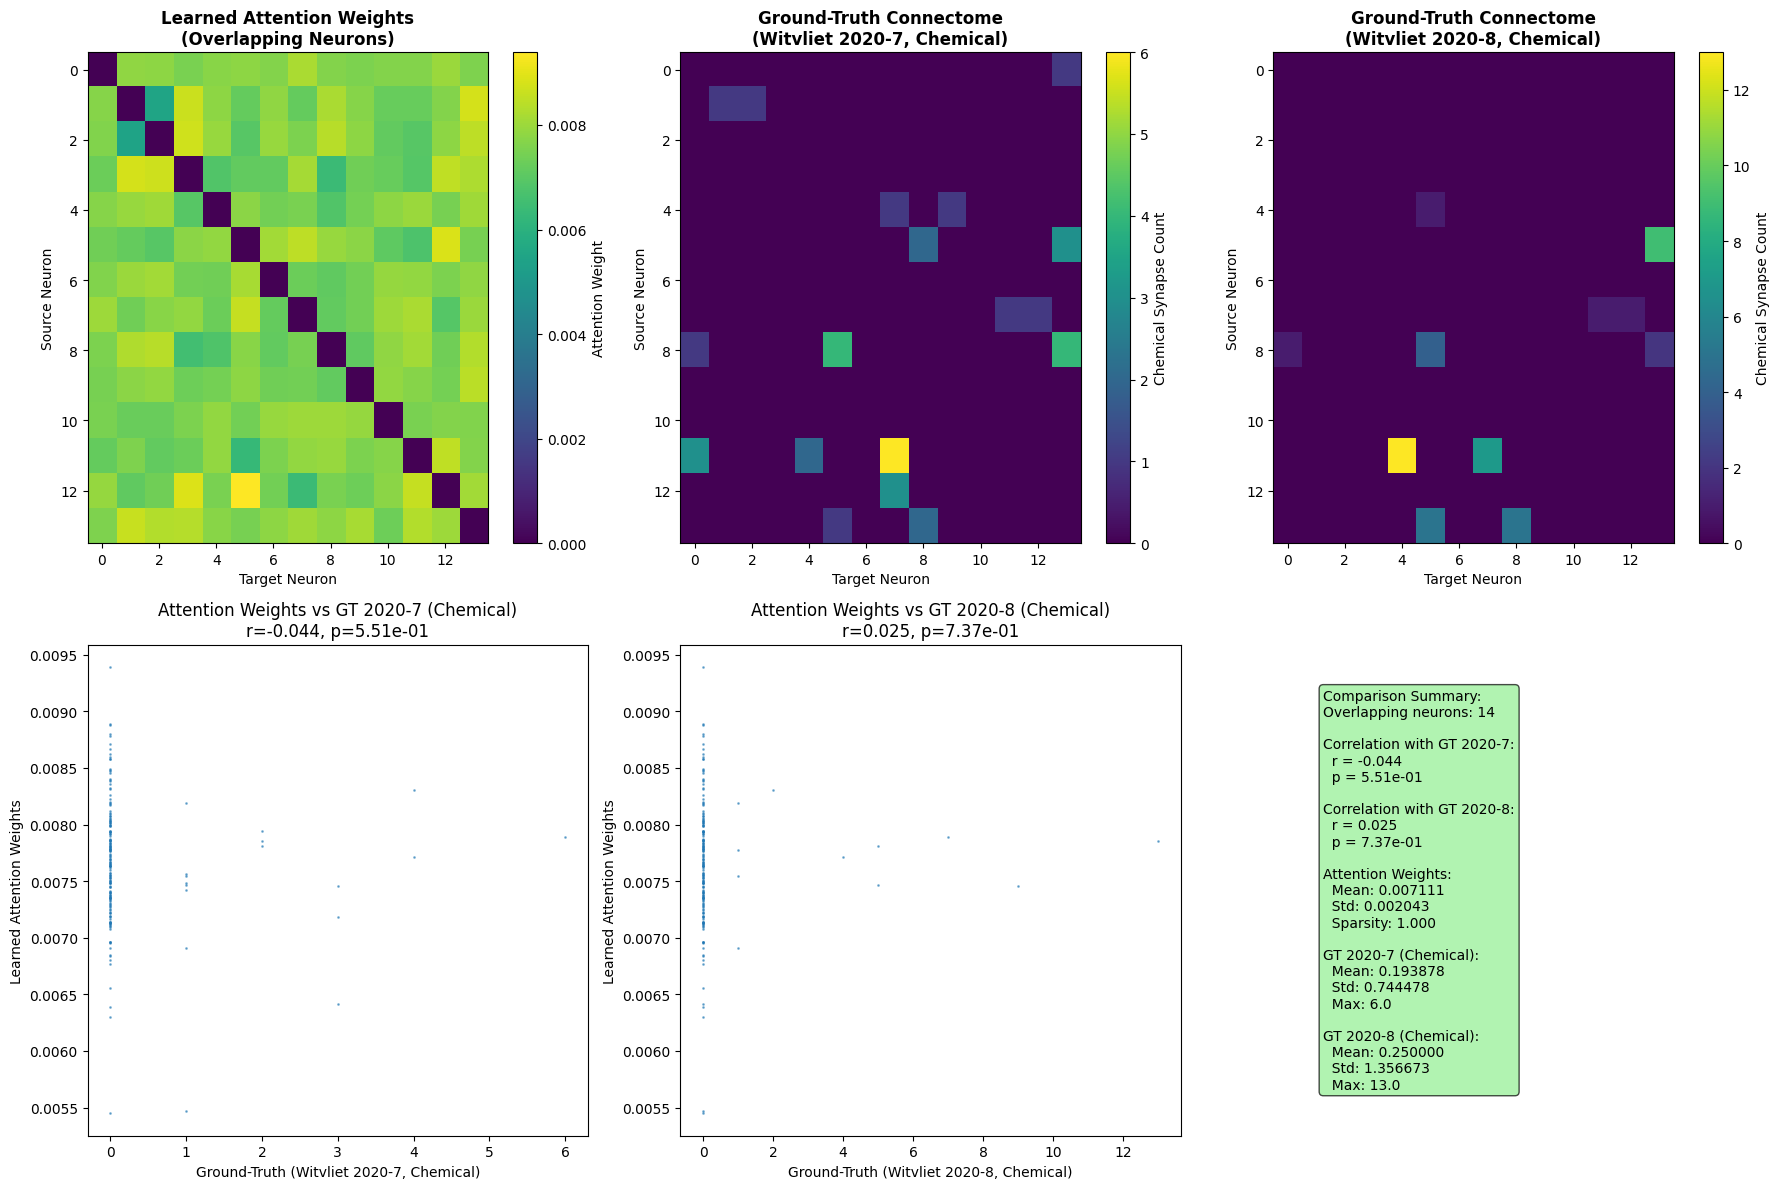


Correlation Analysis:
Attention weights vs Witvliet 2020-7 (Chemical): r=-0.044, p=5.51e-01
Attention weights vs Witvliet 2020-8 (Chemical): r=0.025, p=7.37e-01


In [90]:
# Visualize comparison between learned attention and ground-truth connectomes
print("Creating comparison visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1) Learned attention matrix (subset)
im1 = axes[0, 0].imshow(attention_submatrix, cmap='viridis', aspect='auto')
axes[0, 0].set_title(f'Learned Attention {attention_type.title()}\n(Overlapping Neurons)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Target Neuron')
axes[0, 0].set_ylabel('Source Neuron')
plt.colorbar(im1, ax=axes[0, 0], label=attention_label)

# 2) Ground-truth connectome 2020-7
im2 = axes[0, 1].imshow(gt_adj_7, cmap='viridis', aspect='auto')
axes[0, 1].set_title('Ground-Truth Connectome\n(Witvliet 2020-7, Chemical)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Target Neuron')
axes[0, 1].set_ylabel('Source Neuron')
plt.colorbar(im2, ax=axes[0, 1], label='Chemical Synapse Count')

# 3) Ground-truth connectome 2020-8
im3 = axes[0, 2].imshow(gt_adj_8, cmap='viridis', aspect='auto')
axes[0, 2].set_title('Ground-Truth Connectome\n(Witvliet 2020-8, Chemical)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Target Neuron')
axes[0, 2].set_ylabel('Source Neuron')
plt.colorbar(im3, ax=axes[0, 2], label='Chemical Synapse Count')

# 4) Correlation analysis
from scipy.stats import pearsonr

# Flatten matrices for correlation
attn_flat = attention_submatrix.flatten()
gt_7_flat = gt_adj_7.flatten()
gt_8_flat = gt_adj_8.flatten()

# Remove diagonal elements for correlation (since attention diagonal is always 0)
mask = ~np.eye(attention_submatrix.shape[0], dtype=bool).flatten()
attn_flat_offdiag = attn_flat[mask]
gt_7_flat_offdiag = gt_7_flat[mask]
gt_8_flat_offdiag = gt_8_flat[mask]

corr_7, p_val_7 = pearsonr(attn_flat_offdiag, gt_7_flat_offdiag)
corr_8, p_val_8 = pearsonr(attn_flat_offdiag, gt_8_flat_offdiag)

# Scatter plots
axes[1, 0].scatter(gt_7_flat_offdiag, attn_flat_offdiag, alpha=0.5, s=1)
axes[1, 0].set_xlabel('Ground-Truth (Witvliet 2020-7, Chemical)')
axes[1, 0].set_ylabel(f'Learned Attention {attention_type.title()}')
axes[1, 0].set_title(f'Attention {attention_type.title()} vs GT 2020-7 (Chemical)\nr={corr_7:.3f}, p={p_val_7:.2e}')

axes[1, 1].scatter(gt_8_flat_offdiag, attn_flat_offdiag, alpha=0.5, s=1)
axes[1, 1].set_xlabel('Ground-Truth (Witvliet 2020-8, Chemical)')
axes[1, 1].set_ylabel(f'Learned Attention {attention_type.title()}')
axes[1, 1].set_title(f'Attention {attention_type.title()} vs GT 2020-8 (Chemical)\nr={corr_8:.3f}, p={p_val_8:.2e}')

# 5) Summary statistics
axes[1, 2].axis('off')
summary_text = f"""Comparison Summary:
Overlapping neurons: {len(overlap_neurons)}

Correlation with GT 2020-7:
  r = {corr_7:.3f}
  p = {p_val_7:.2e}

Correlation with GT 2020-8:
  r = {corr_8:.3f}
  p = {p_val_8:.2e}

Attention {attention_type.title()}:
  Mean: {attention_submatrix.mean():.6f}
  Std: {attention_submatrix.std():.6f}
  Sparsity: {(attention_weights_matrix[np.ix_(overlap_indices, overlap_indices)] < 0.01).sum() / attention_submatrix.size:.3f}

GT 2020-7 (Chemical):
  Mean: {gt_adj_7.mean():.6f}
  Std: {gt_adj_7.std():.6f}
  Max: {gt_adj_7.max():.1f}

GT 2020-8 (Chemical):
  Mean: {gt_adj_8.mean():.6f}
  Std: {gt_adj_8.std():.6f}
  Max: {gt_adj_8.max():.1f}"""

axes[1, 2].text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\nCorrelation Analysis:")
print(f"Attention {attention_type} vs Witvliet 2020-7 (Chemical): r={corr_7:.3f}, p={p_val_7:.2e}")
print(f"Attention {attention_type} vs Witvliet 2020-8 (Chemical): r={corr_8:.3f}, p={p_val_8:.2e}")


## 9. Functional Connectome Data Loading and Analysis

Now let's compare our learned attention matrix with functional connectome data from Randi et al. (2023). This data provides functional connectivity measures based on neural signal propagation experiments, which may be more relevant for comparing with our transcriptome-based attention model.


Loading functional connectome data...
Functional connectivity matrix shape: (168, 168)
Significance matrix shape: (168, 168)

Functional connectivity matrix sample:
          ADEL      ADER      ADFL      ADLL      ADLR      AFDL      AFDR  \
ADEL  0.919629  0.490587  0.117402 -0.011007       NaN       NaN  0.016940   
ADER  0.282736  0.365724 -0.089438       NaN -0.061270  0.000030  0.117529   
ADFL -0.016994 -0.004794  0.149321       NaN  0.038435       NaN  0.102787   
ADLL -0.135569  0.102390 -0.059664  0.271304  0.199479 -0.028692 -0.023775   
ADLR       NaN -0.004710  0.020147  0.258942  0.383452  0.075811 -0.010418   

           AQR      ASEL      ASER  ...     SMBDR     SMBVL     SMBVR  \
ADEL  0.102774  0.029621 -0.079443  ...       NaN       NaN -0.132959   
ADER  0.980210 -0.011183       NaN  ...       NaN -0.024409       NaN   
ADFL       NaN  0.127345       NaN  ...       NaN  0.027724       NaN   
ADLL -0.035640  0.327081  0.433933  ... -0.003473  0.185044       NaN   
A

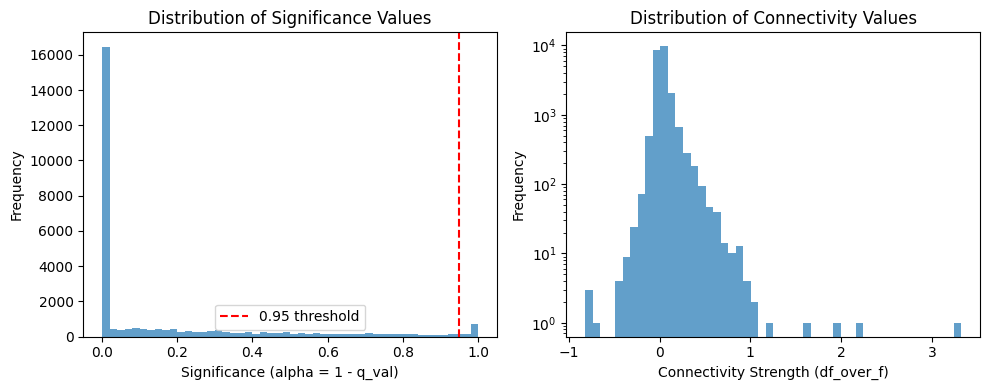

In [30]:
# Load and analyze functional connectome data from CElegansFunctionalConnectivity.xlsx
print("Loading functional connectome data...")

# Load the Excel file
xls = pd.ExcelFile("data/CElegansFunctionalConnectivity.xlsx")

# Load the data from the first and second sheets
df_connectivity = pd.read_excel(xls, sheet_name="Figure2a, df_over_f", index_col=0)
df_significance = pd.read_excel(xls, sheet_name="Figure2a, alpha=(1 - q_val)", index_col=0)

print(f"Functional connectivity matrix shape: {df_connectivity.shape}")
print(f"Significance matrix shape: {df_significance.shape}")

# Display sample data
print(f"\nFunctional connectivity matrix sample:")
print(df_connectivity.head())
print(f"\nSignificance matrix sample:")
print(df_significance.head())

# Check overlap with our transcriptome neuron classes
func_neurons = set(df_connectivity.index)
transcriptome_neurons = set(neuron_classes)
overlap_func = transcriptome_neurons.intersection(func_neurons)

print(f"\nOverlap analysis:")
print(f"Functional connectome neurons: {len(func_neurons)}")
print(f"Transcriptome neurons: {len(transcriptome_neurons)}")
print(f"Overlap: {len(overlap_func)}/{len(transcriptome_neurons)} ({len(overlap_func)/len(transcriptome_neurons)*100:.1f}%)")

# Show some overlapping neurons
print(f"\nSample overlapping neurons: {list(overlap_func)[:10]}")

# Analyze the significance threshold distribution
print(f"\nSignificance matrix statistics:")
print(f"Mean significance: {df_significance.values.flatten().mean():.3f}")
print(f"Std significance: {df_significance.values.flatten().std():.3f}")
print(f"Max significance: {df_significance.values.flatten().max():.3f}")
print(f"Min significance: {df_significance.values.flatten().min():.3f}")

# Show distribution of significance values
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_significance.values.flatten(), bins=50, alpha=0.7)
plt.xlabel('Significance (alpha = 1 - q_val)')
plt.ylabel('Frequency')
plt.title('Distribution of Significance Values')
plt.axvline(x=0.95, color='red', linestyle='--', label='0.95 threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_connectivity.values.flatten(), bins=50, alpha=0.7)
plt.xlabel('Connectivity Strength (df_over_f)')
plt.ylabel('Frequency')
plt.title('Distribution of Connectivity Values')
plt.yscale('log')

plt.tight_layout()
plt.show()


In [31]:
# Create functional connectome matrices for overlapping neurons
print("Creating functional connectome matrices for overlapping neurons...")

# Use overlapping neurons from functional connectome
overlap_func_list = list(overlap_func)
print(f"Using {len(overlap_func_list)} overlapping neurons for functional connectome comparison")

# Reindex the dataframe to match the overlapping neurons
func_connectivity_matrix = df_connectivity.reindex(
    index=overlap_func_list, columns=overlap_func_list, fill_value=0
)

print(f"Functional connectivity matrix shape: {func_connectivity_matrix.shape}")

# Create corresponding attention submatrix for overlapping neurons
func_overlap_indices = [neuron_classes.index(neuron) for neuron in overlap_func_list]
func_attention_submatrix = attention_matrix[np.ix_(func_overlap_indices, func_overlap_indices)]

print(f"Attention submatrix shape: {func_attention_submatrix.shape}")

print(f"\nMatrix statistics:")
print(f"Functional connectivity: mean={func_connectivity_matrix.values.mean():.6f}, std={func_connectivity_matrix.values.std():.6f}, max={func_connectivity_matrix.values.max():.6f}")
print(f"Attention {attention_type}: mean={func_attention_submatrix.mean():.6f}, std={func_attention_submatrix.std():.6f}, max={func_attention_submatrix.max():.6f}")

# Analyze NaN values in functional data
n_nans = np.isnan(func_connectivity_matrix.values).sum()
n_total = func_connectivity_matrix.size
print(f"\nNaN analysis:")
print(f"Functional connectome: {n_nans}/{n_total} ({n_nans/n_total*100:.1f}%) NaN values")


Creating functional connectome matrices for overlapping neurons...
Using 16 overlapping neurons for functional connectome comparison
Functional connectivity matrix shape: (16, 16)
Attention submatrix shape: (16, 16)

Matrix statistics:
Functional connectivity: mean=nan, std=nan, max=nan
Attention weights: mean=0.017513, std=0.085567, max=0.874001

NaN analysis:
Functional connectome: 43/256 (16.8%) NaN values


Creating functional connectome comparison visualizations...
Valid data points for correlation: 197/240


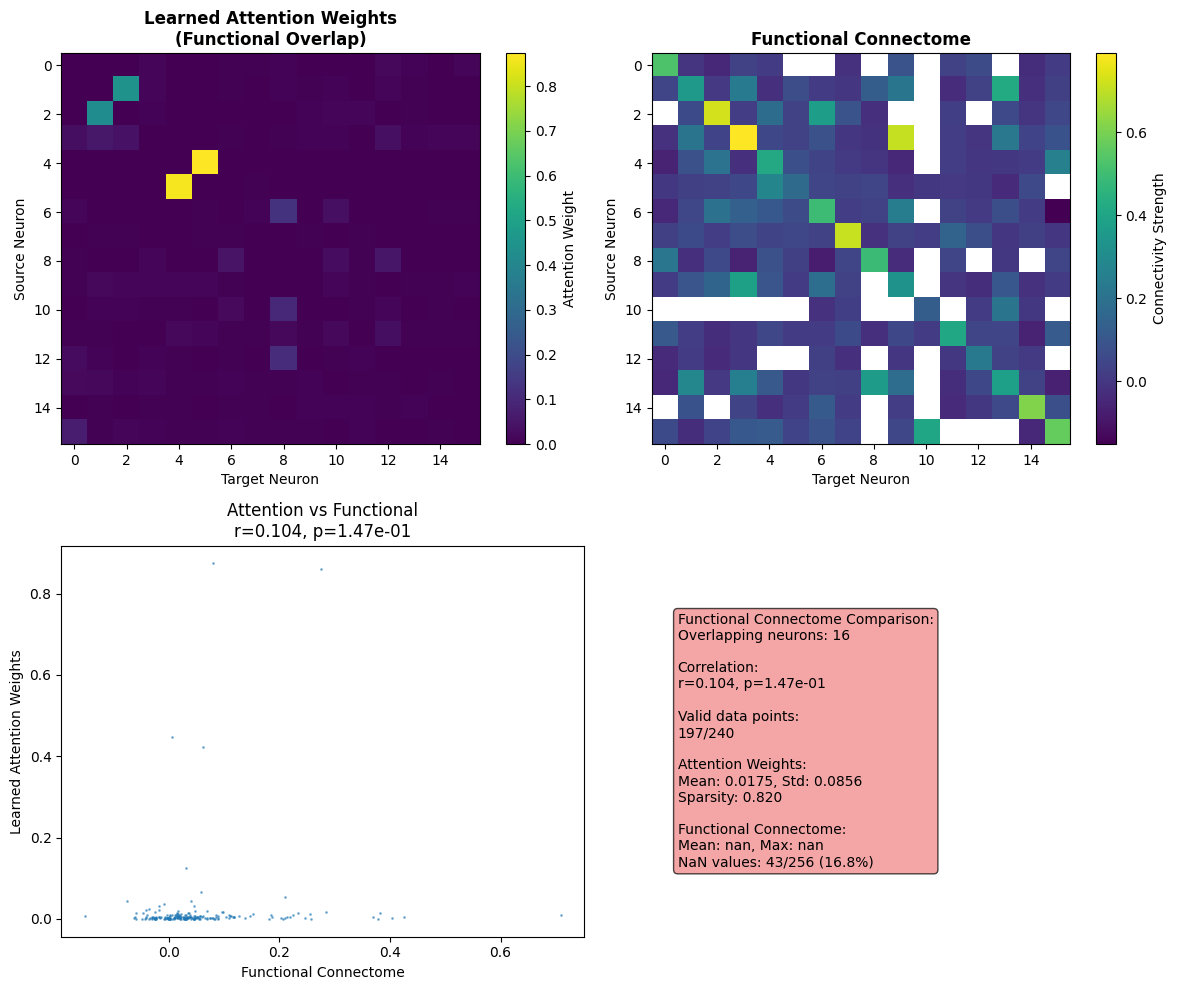


Functional Connectome Correlation Analysis:
Attention weights vs Functional: r=0.104, p=1.47e-01 (n=197)


In [32]:
# Visualize comparison between learned attention and functional connectome
print("Creating functional connectome comparison visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Learned attention matrix (subset)
im1 = axes[0, 0].imshow(func_attention_submatrix, cmap='viridis', aspect='auto')
axes[0, 0].set_title(f'Learned Attention {attention_type.title()}\n(Functional Overlap)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Target Neuron')
axes[0, 0].set_ylabel('Source Neuron')
plt.colorbar(im1, ax=axes[0, 0], label=attention_label)

# 2) Functional connectome
im2 = axes[0, 1].imshow(func_connectivity_matrix, cmap='viridis', aspect='auto')
axes[0, 1].set_title('Functional Connectome', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Target Neuron')
axes[0, 1].set_ylabel('Source Neuron')
plt.colorbar(im2, ax=axes[0, 1], label='Connectivity Strength')

# 3) Correlation analysis
from scipy.stats import pearsonr

# Flatten matrices for correlation
attn_flat = func_attention_submatrix.flatten()
func_flat = func_connectivity_matrix.values.flatten()

# Remove diagonal elements for correlation (since attention diagonal is always 0)
mask = ~np.eye(func_attention_submatrix.shape[0], dtype=bool).flatten()
attn_flat_offdiag = attn_flat[mask]
func_flat_offdiag = func_flat[mask]

# Handle NaN values in functional data
# Remove pairs where either attention or functional data is NaN
valid_mask = ~(np.isnan(attn_flat_offdiag) | np.isnan(func_flat_offdiag))
attn_valid = attn_flat_offdiag[valid_mask]
func_valid = func_flat_offdiag[valid_mask]

print(f"Valid data points for correlation: {len(attn_valid)}/{len(attn_flat_offdiag)}")

# Calculate correlation only on valid data
if len(attn_valid) > 1:
    corr, p_val = pearsonr(attn_valid, func_valid)
else:
    corr, p_val = np.nan, np.nan

# Scatter plot (using valid data only)
axes[1, 0].scatter(func_valid, attn_valid, alpha=0.5, s=1)
axes[1, 0].set_xlabel('Functional Connectome')
axes[1, 0].set_ylabel(f'Learned Attention {attention_type.title()}')
if not np.isnan(corr):
    axes[1, 0].set_title(f'Attention vs Functional\nr={corr:.3f}, p={p_val:.2e}')
else:
    axes[1, 0].set_title(f'Attention vs Functional\nInsufficient valid data')

# 4) Summary statistics
axes[1, 1].axis('off')

# Format correlation values safely
corr_str = f"{corr:.3f}" if not np.isnan(corr) else "nan"
p_val_str = f"{p_val:.2e}" if not np.isnan(p_val) else "nan"

summary_text = f"""Functional Connectome Comparison:
Overlapping neurons: {len(overlap_func_list)}

Correlation:
r={corr_str}, p={p_val_str}

Valid data points:
{len(attn_valid)}/{len(attn_flat_offdiag)}

Attention {attention_type.title()}:
Mean: {func_attention_submatrix.mean():.4f}, Std: {func_attention_submatrix.std():.4f}
Sparsity: {(attention_weights_matrix[np.ix_(func_overlap_indices, func_overlap_indices)] < 0.01).sum() / func_attention_submatrix.size:.3f}

Functional Connectome:
Mean: {func_connectivity_matrix.values.mean():.4f}, Max: {func_connectivity_matrix.values.max():.4f}
NaN values: {n_nans}/{n_total} ({n_nans/n_total*100:.1f}%)"""

axes[1, 1].text(0.05, 0.5, summary_text, fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\nFunctional Connectome Correlation Analysis:")
if not np.isnan(corr):
    print(f"Attention {attention_type} vs Functional: r={corr:.3f}, p={p_val:.2e} (n={len(attn_valid)})")
else:
    print(f"Attention {attention_type} vs Functional: Insufficient valid data (n={len(attn_valid)})")
